In [ ]:
import sys
sys.path.insert(0, '..')

# =====================================================
# SETUP AND DATA LOADING
# =====================================================
# This section imports necessary libraries and loads the panel data
# that was previously extracted from game runs.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Import utility functions from plot_utilities
from plot_utilities import (
    load_panel_data,
    setup_notebook_display,
    prepare_coefficient_data,
    plot_forest_plot
)

# Set up notebook display and plotting style
setup_notebook_display(figsize=(10, 6))

# Load panel data using the unified function
panel_df = load_panel_data('../panel_data.csv')

## Linear Regression Analysis on Score Ratio

This notebook performs linear regression to identify factors that influence score ratio in the game. We analyze:

1. **LLM Strategist (Conditions)**: How different LLM strategists affect score ratio compared to vanilla gameplay
2. **Civilizations**: Which civilizations achieve higher or lower score ratios
3. **Player Effects**: Controlling for individual player skill differences

### Model Specification

We use a linear regression model with:
- **Dependent variable**: `score_ratio` (continuous: 0 to 1, representing player's share of total score)
- **Independent variables**: 
  - Player fixed effects (to control for skill differences)
  - Civilization fixed effects
  - Condition with "Vanilla Game" as the baseline

The model estimates marginal effects on score ratio, which can be directly interpreted as percentage point changes.

In [7]:
# =====================================================
# FIT LINEAR REGRESSION MODEL
# =====================================================
# This section fits the main linear regression model using statsmodels.
# The model includes fixed effects for players, civilizations, and conditions.

import statsmodels.api as sm
from statsmodels.formula.api import ols
from patsy.contrasts import Sum

print("=" * 60)
print("LINEAR REGRESSION: score_ratio")
print("=" * 60)

# Model specification with treatment coding for conditions and deviation coding for civilizations
# Vanilla Game (no LLM strategist) serves as the baseline for conditions
# Deviation coding (Sum) for civilizations centers effects around the mean
formula = 'score_ratio ~ C(civilization, Sum) + C(player_type, Treatment(reference="Vanilla"))'
model = ols(formula, data=panel_df).fit()

print("\nModel: Player ID, Civilization, and Condition Fixed Effects")
print("Baseline category for condition: Vanilla Game")
print("Civilization coding: Deviation (Sum) - effects relative to mean")
print(model.summary())

LINEAR REGRESSION: score_ratio

Model: Player ID, Civilization, and Condition Fixed Effects
Baseline category for condition: Vanilla Game
Civilization coding: Deviation (Sum) - effects relative to mean
                            OLS Regression Results                            
Dep. Variable:            score_ratio   R-squared:                       0.094
Model:                            OLS   Adj. R-squared:                  0.076
Method:                 Least Squares   F-statistic:                     5.307
Date:                Thu, 12 Feb 2026   Prob (F-statistic):           2.55e-30
Time:                        20:53:03   Log-Likelihood:                -374.25
No. Observations:                2720   AIC:                             854.5
Df Residuals:                    2667   BIC:                             1168.
Df Model:                          52                                         
Covariance Type:            nonrobust                                         
        

In [8]:
# =====================================================
# PREPARE DATA FOR VISUALIZATION
# =====================================================
# Extract coefficients and prepare data for forest plots using utility functions

# Get model results
params = model.params
conf_int = model.conf_int()
pvalues = model.pvalues

# Extract and prepare condition effects (LLM strategist)
condition_vars = [col for col in params.index if 'player_type' in col and col != 'Intercept']
condition_df = prepare_coefficient_data(params, conf_int, pvalues, condition_vars, var_type='condition')

# Extract and prepare civilization effects
civ_vars = [col for col in params.index if 'civilization' in col]
civ_df = prepare_coefficient_data(params, conf_int, pvalues, civ_vars, var_type='civilization')

# Calculate civilization effects relative to mean (instead of arbitrary baseline)
# This approach uses the average civilization as the baseline, making the results
# more interpretable and avoiding bias from an arbitrary reference category

print("=" * 60)
print("DATA PREPARATION COMPLETE")
print("=" * 60)
print(f"\nCondition effects extracted: {len(condition_df)}")
print(f"Civilization effects extracted: {len(civ_df)}")
print("\nNote: Civilization effects are shown relative to the average civilization")
print("performance rather than an arbitrary baseline civilization.")

DATA PREPARATION COMPLETE

Condition effects extracted: 10
Civilization effects extracted: 42

Note: Civilization effects are shown relative to the average civilization
performance rather than an arbitrary baseline civilization.


## Visualization of Marginal Effects

### Interpretation Guide

**Marginal Effects in Linear Regression:**
- The coefficients represent the change in score ratio (0-1 scale)
- Positive values indicate increased score share relative to the baseline
- Negative values indicate decreased score share relative to the baseline
- The baseline for conditions is "Vanilla Game" (no LLM strategist)
- The baseline for civilizations is the mean across all civilizations

**Confidence Intervals:**
- 95% CI shows the range where the true effect likely falls
- If the CI crosses zero, the effect is not statistically significant at p < 0.05
- Wider CIs indicate more uncertainty in the estimate


Effect of LLM Strategist on Score Ratio
(95% Confidence Intervals) SUMMARY

Baseline: (Vanilla baseline)

Statistically Significant Effects (p < 0.05):
----------------------------------------
  Deepseek-3.2-Simple            -0.082 [-0.160, -0.005] *
  GLM-4.7-Briefed                -0.062 [-0.112, -0.012] *
  GPT-OSS-120B-Briefed           -0.101 [-0.160, -0.042] ***
  GPT-OSS-120B-Simple            -0.076 [-0.135, -0.017] *
  Sonnet-4.5-Briefed             -0.171 [-0.277, -0.066] **

Non-Significant Effects:
----------------------------------------
  Deepseek-3.2-Briefed           -0.073 [-0.151, +0.004]
  GLM-4.7-Simple                 -0.045 [-0.095, +0.005]
  Kimi-K2-Briefed                +0.057 [-0.020, +0.134]
  Kimi-K2-Simple                 +0.035 [-0.042, +0.112]
  Sonnet-4.5-Simple              -0.022 [-0.127, +0.083]

Overall Statistics:
----------------------------------------
  Total effects analyzed: 10
  Significant effects: 5 (50.0%)


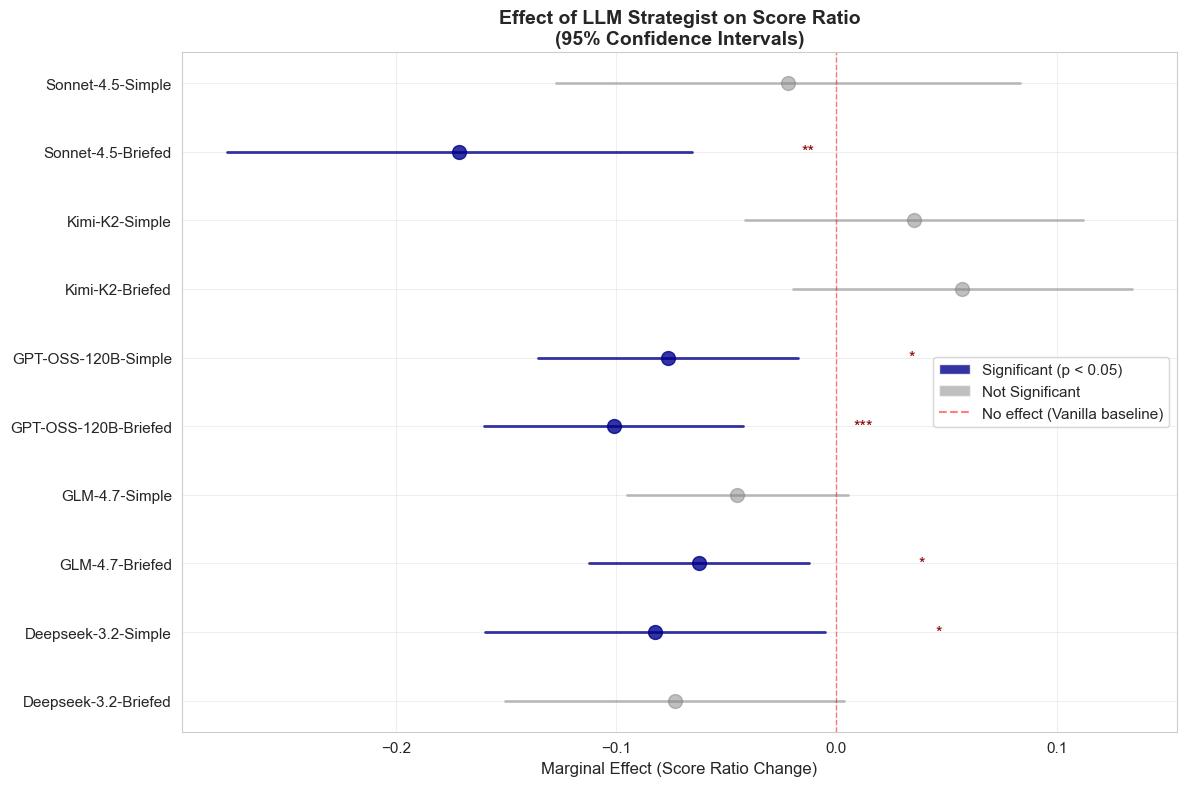

In [9]:
# =====================================================
# VISUALIZATION 1: LLM STRATEGIST EFFECTS
# =====================================================
# Create forest plot showing how LLM strategists affect score ratio
# compared to vanilla gameplay (no LLM strategist)

# Create forest plot for conditions with integrated summary
fig, ax = plot_forest_plot(
    condition_df, 
    title='Effect of LLM Strategist on Score Ratio\n(95% Confidence Intervals)',
    xlabel='Marginal Effect (Score Ratio Change)',
    color='darkblue',
    figsize=(12, 8),
    reference_line_label='No effect (Vanilla baseline)',
    use_prob_scale=False,  # Use raw scale for score ratio
    sort_alphabetically=True
)

plt.show()


Civilization Effects on Score Ratio
(Relative to Mean, 95% Confidence Intervals) SUMMARY

Baseline: Average of all civilization effect

Statistically Significant Effects (p < 0.05):
----------------------------------------
  Assyria                        -0.114 [-0.180, -0.048] ***
  Mongolia                       -0.109 [-0.176, -0.042] **
  Korea                          -0.106 [-0.176, -0.036] **
  Persia                         -0.103 [-0.165, -0.042] **
  America                        -0.103 [-0.169, -0.036] **
  Egypt                          -0.101 [-0.174, -0.028] **
  Ethiopia                       -0.101 [-0.171, -0.031] **
  Japan                          -0.095 [-0.155, -0.035] **
  Denmark                        -0.084 [-0.151, -0.017] *
  Rome                           -0.082 [-0.149, -0.015] *
  Brazil                         +0.085 [+0.016, +0.153] *
  The Netherlands                +0.107 [+0.041, +0.173] **
  Spain                          +0.121 [+0.055, +0.187] *

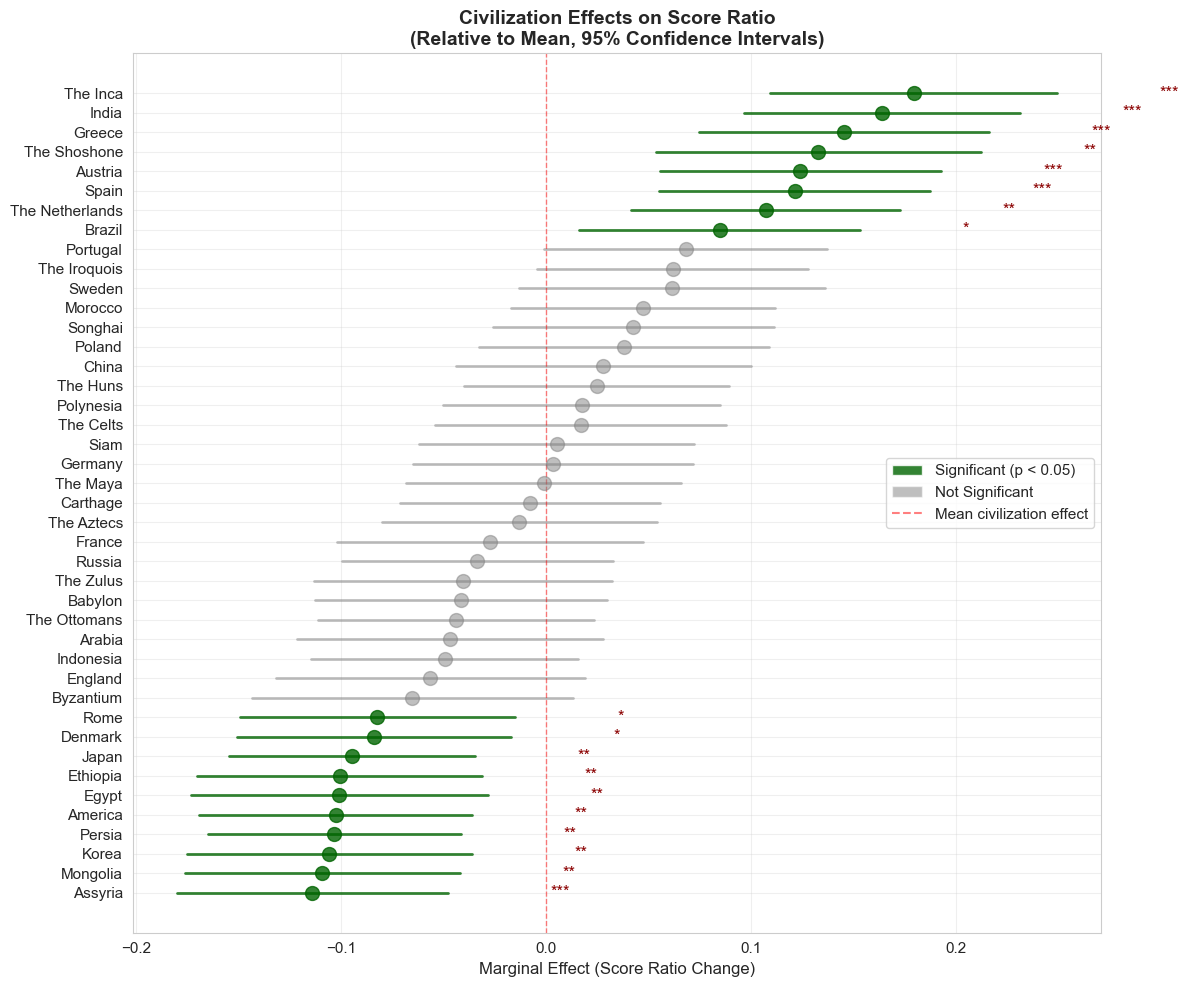

In [10]:
# =====================================================
# VISUALIZATION 2: CIVILIZATION EFFECTS (RELATIVE TO MEAN)
# =====================================================
# Create forest plot showing civilization strength relative to the mean
# This approach uses the average civilization performance as the baseline

# Create forest plot for civilizations with integrated summary
fig, ax = plot_forest_plot(
    civ_df,
    title='Civilization Effects on Score Ratio\n(Relative to Mean, 95% Confidence Intervals)',
    xlabel='Marginal Effect (Score Ratio Change)',
    color='darkgreen',
    figsize=(12, 10),
    reference_line_label='Mean civilization effect',
    use_prob_scale=False,  # Use raw scale for score ratio
)

plt.show()